# Detection

In [ ]:
import torch
import numpy as np
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pathlib import Path
from torch import nn, optim
from torch.utils.data import DataLoader
from datetime import datetime
import matplotlib.pyplot as plt
import torch.nn.functional as F
from collections import Counter
from itertools import product
import math
import hashlib
import io
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import patches
from matplotlib.patches import Patch
import json

### Setup

In [ ]:
SEED = 265
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float32)

In [ ]:
IMG_HEIGHT, IMG_WIDTH = 48, 60
DATA_DIR = Path("data")
BATCH_SIZE = 32

In [ ]:
EPOCH_INVESTIGATE_POINTS = [2,4,6,8,10]
MAX_EPOCHS = 10

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

Training on device cpu.


In [ ]:
DO_TRAINING = True  # Set me to TRUE to run training from the start, otherwise we just load existing models

In [ ]:
save_dir = Path("imgs/object_detection")
save_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
def compute_rmse_arrs(actual_bb, pred_bb):
    actual_bb = torch.as_tensor(actual_bb)
    pred_bb = torch.as_tensor(pred_bb)
    criterion = nn.MSELoss()
    mse = criterion(pred_bb, actual_bb)
    return torch.sqrt(mse).item()

In [ ]:
def intersection_union(pred, true):
    # Unpack [z, x_center, y_center, width, height]
    # Convert to corners [x1, y1, x2, y2]
    def to_corners(box):
        xc, yc, w, h = box[1], box[2], box[3], box[4]
        return xc - w/2, yc - h/2, xc + w/2, yc + h/2

    p_x1, p_y1, p_x2, p_y2 = to_corners(pred)
    t_x1, t_y1, t_x2, t_y2 = to_corners(true)

    # Calculate intersection boundaries
    i_x1 = torch.max(p_x1, t_x1)
    i_y1 = torch.max(p_y1, t_y1)
    i_x2 = torch.min(p_x2, t_x2)
    i_y2 = torch.min(p_y2, t_y2)

    # Width and height of intersection (clamp to 0 if no overlap)
    inter_w = torch.clamp(i_x2 - i_x1, min=0)
    inter_h = torch.clamp(i_y2 - i_y1, min=0)
    intersection = inter_w * inter_h

    # Areas
    area_p = torch.clamp(p_x2 - p_x1, min=0) * torch.clamp(p_y2 - p_y1, min=0)
    area_t = torch.clamp(t_x2 - t_x1, min=0) * torch.clamp(t_y2 - t_y1, min=0)

    union = area_p + area_t - intersection

    return union.item(), intersection.item()

def compute_performance_metrics(model, loader):
    model.eval()

    object_matches, class_matches, iou_total = 0, 0, 0

    total, total_including_obj = 0, 0

    with torch.no_grad():
        for images, labels in loader:

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            for output, label in zip(outputs, labels):  # loop over each sample
                total += 1

                pred_has_object = (torch.sigmoid(output[0]) > 0.5).float()
                actual_object = label[0]

                # accuracy of object / no object
                if pred_has_object == actual_object:
                    object_matches+=1

                # if actually a class to evaluate
                if actual_object == 1:
                    total_including_obj += 1

                    # run iou
                    union, intersection = intersection_union(output, label)

                    current_iou = (intersection / union) if union > 1e-7 else 0
                    iou_total += current_iou

                    # accuracy of class
                    if label[5] == output[5:].argmax():
                        class_matches+=1

    # object accuracy
    obj_acc = object_matches / total

    # iou score
    iou_score = iou_total / max(total_including_obj, 1)

    # only look at those with actual class
    class_acc = class_matches / max(total_including_obj, 1)

    return iou_score, obj_acc, class_acc


### Load data and preprocessing

In [ ]:
dataset_train = torch.load(DATA_DIR / f"localization_train.pt", weights_only = False)
dataset_val = torch.load(DATA_DIR / f"localization_val.pt", weights_only = False)
dataset_test = torch.load(DATA_DIR / f"localization_test.pt", weights_only = False)

In [ ]:
print(len(dataset_train))
# Looks like a good amount of data

59400


In [ ]:
dataset_train[5][1] # this image has no object, but the class label is 1!, we need to fix this to help plotting later

tensor([ 0., -1., -1., -1., -1.,  1.])

Looks ok, but seems like the image bounding box coords have also been scaled, lets take that into account when plotting

In [ ]:
def make_no_object_to_class_lbl_10(sample):
    img, vec = sample
    if vec[0] == 0:
        vec[5] = -1 # no class
    return img, vec


dataset_train = [make_no_object_to_class_lbl_10(sample) for sample in dataset_train]
dataset_val = [make_no_object_to_class_lbl_10(sample) for sample in dataset_val]
dataset_test = [make_no_object_to_class_lbl_10(sample) for sample in dataset_test]

In [ ]:
print(dataset_train[5][1]) # looks good now

tensor([ 0., -1., -1., -1., -1., -1.])


In [ ]:
def scale_vars(x,y,w,h):
    # since imgs are normalized we should scale them first to plot them correctly
    scaled_x = x*IMG_WIDTH
    scaled_w = w*IMG_WIDTH
    scaled_y = y*IMG_HEIGHT
    scaled_h = h*IMG_HEIGHT

    scaled_x = scaled_x - scaled_w / 2
    scaled_y = scaled_y - scaled_h / 2

    return scaled_x, scaled_y, scaled_w, scaled_h

In [ ]:
def plot_image(img_tensor, ax):
    img_pixels = img_tensor[0]
    is_item, x, y, w, h, class_label = img_tensor[1]

    img = img_pixels.permute(1, 2, 0)

    scaled_x, scaled_y, scaled_w, scaled_h = scale_vars(x,y,w,h)

    ax.imshow(img)
    ax.add_patch(
        patches.Rectangle((scaled_x, scaled_y), scaled_w, scaled_h, linewidth=5, edgecolor='r', facecolor='none')
    )

    ax.set_title(f"Image with class {int(class_label)}, is item = {int(is_item)}")
    return ax

def plot_image_with_prediction(img_tensor, ax, predicted_box: list):
    """
    predicted box = [x,y,w,h]
    """
    # if ax is None:
        # make own ax
    img_pixels = img_tensor[0]
    is_item, x, y, w, h, class_label = img_tensor[1]

    img = img_pixels.permute(1, 2, 0)

    scaled_x, scaled_y, scaled_w, scaled_h = scale_vars(x,y,w,h)


    ax.imshow(img)
    ax.add_patch(
        patches.Rectangle((scaled_x, scaled_y), scaled_w, scaled_h, linewidth=5, edgecolor='r', facecolor='none')
    )

    pred_x, pred_y, pred_w, pred_h = predicted_box
    scaled_x_pred, scaled_y_pred, scaled_w_pred, scaled_h_pred = scale_vars(pred_x,pred_y,pred_w,pred_h)

    ax.add_patch(
        patches.Rectangle((scaled_x_pred, scaled_y_pred), scaled_w_pred, scaled_h_pred, linewidth=5, edgecolor='y', facecolor='none')
    )

    ax.legend(
        ["red", "yellow"],
        ["actual", "predicted"]
    )

    ax.set_title(f"Image with class {int(class_label)}, is item = {int(is_item)}")
    return ax

In [ ]:
def plot_multiple_with_prediction(indicies: list, prediction: list, title: str, dataset, model_title):
    n = len(indicies)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    fig.suptitle(f"{title}", fontsize=16)

    for ax, index in zip(axes, indicies):
        plot_image_with_prediction(dataset[index], ax, prediction[index])

    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(save_dir / f"{model_title}.png", dpi=500)

    plt.show()

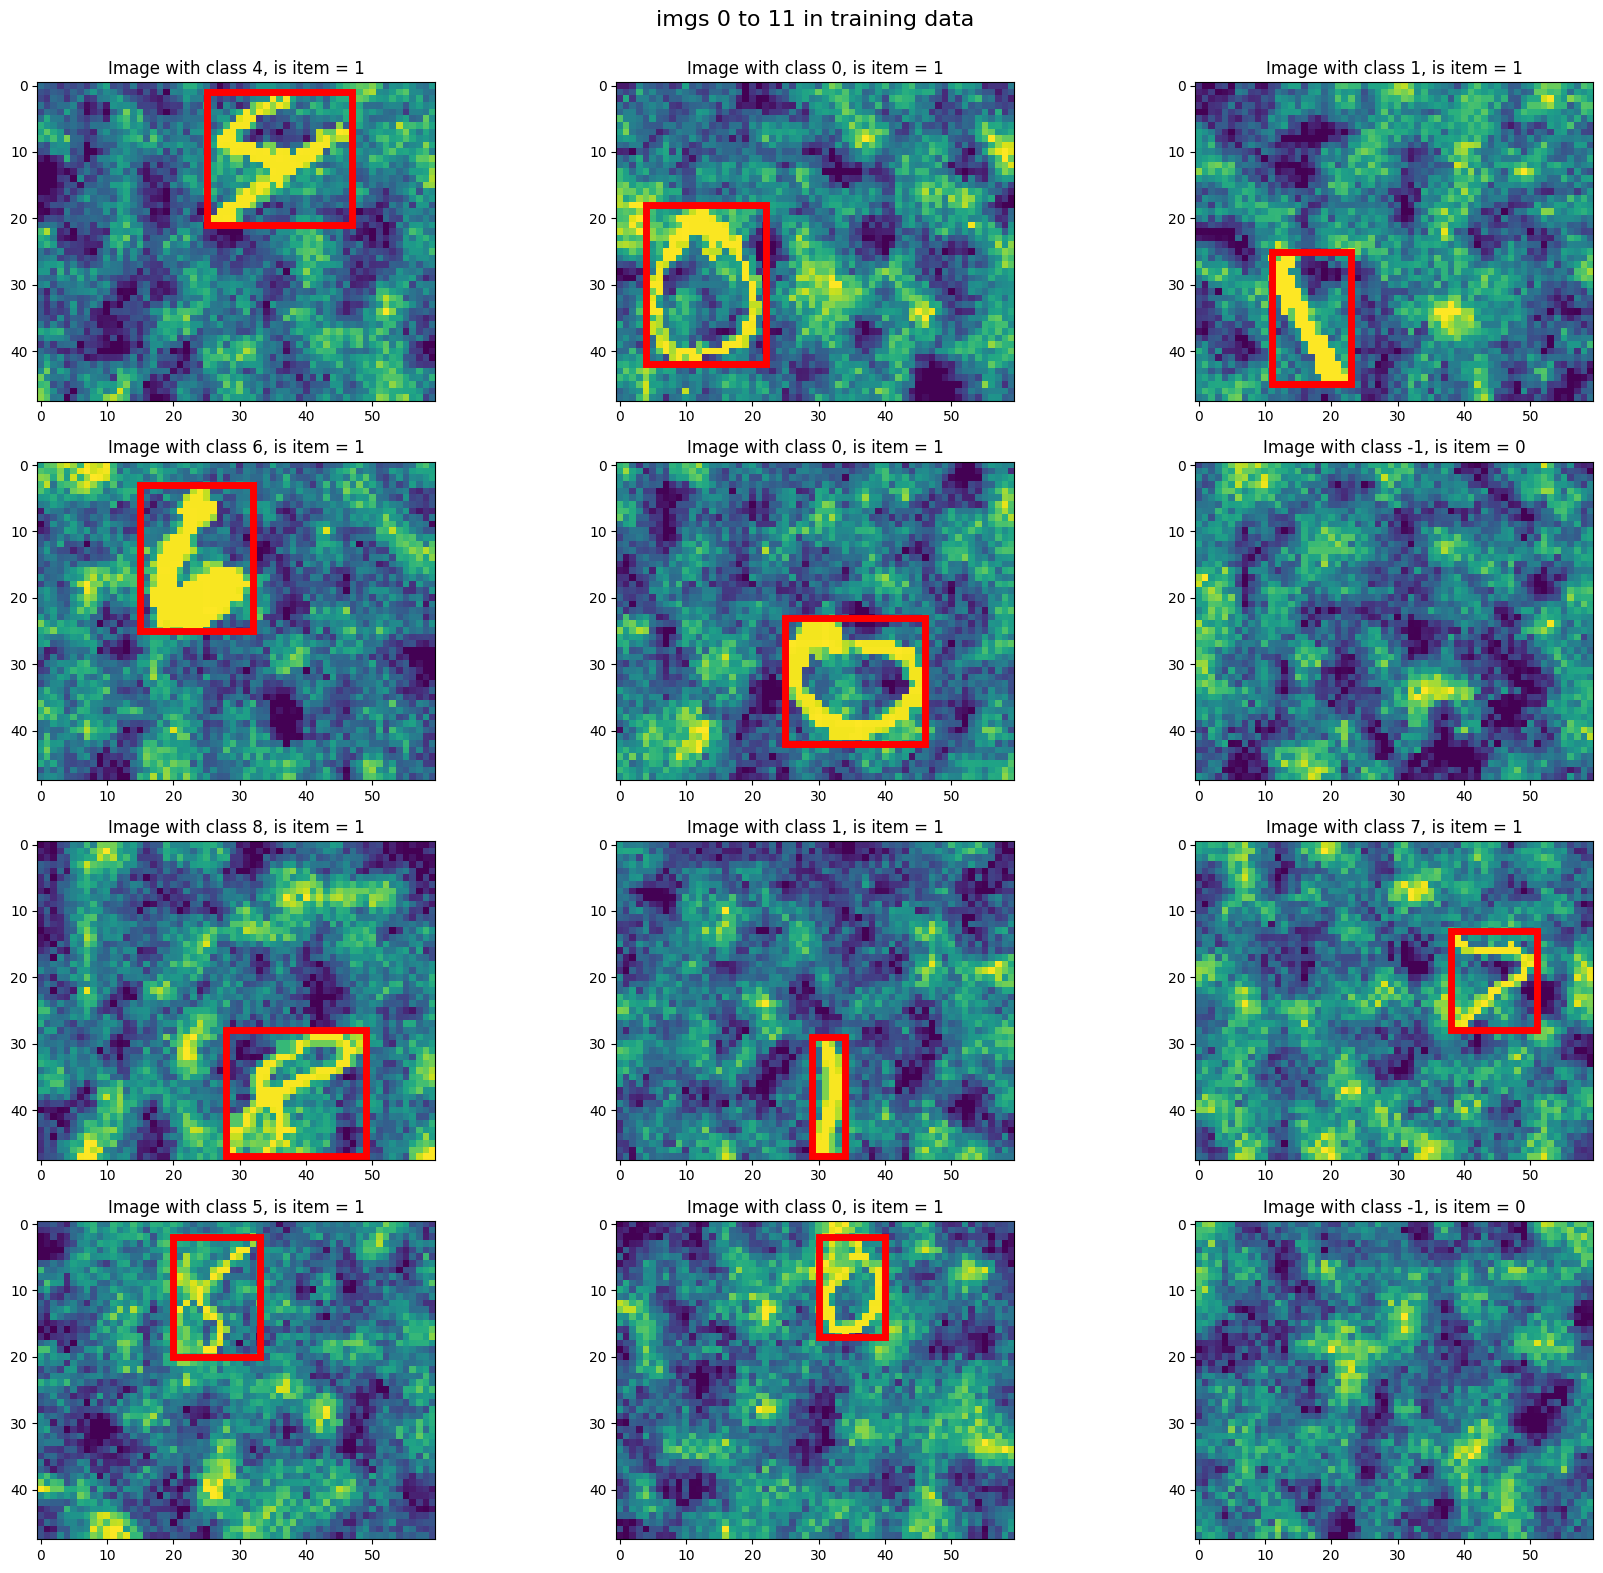

In [ ]:
def plot_multiple(indicies: list, title: str, dataset, model_title):
    n = len(indicies)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    fig.suptitle(f"{title}", fontsize=16)

    for ax, index in zip(axes, indicies):
        plot_image(dataset[index], ax)

    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(save_dir / f"{model_title}.png", dpi=500)

    plt.show()

plot_multiple(
    [i for i in range(12)],
    "imgs 0 to 11 in training data",
    dataset_train,
    "data_explore_train"
)

Ok looks good!

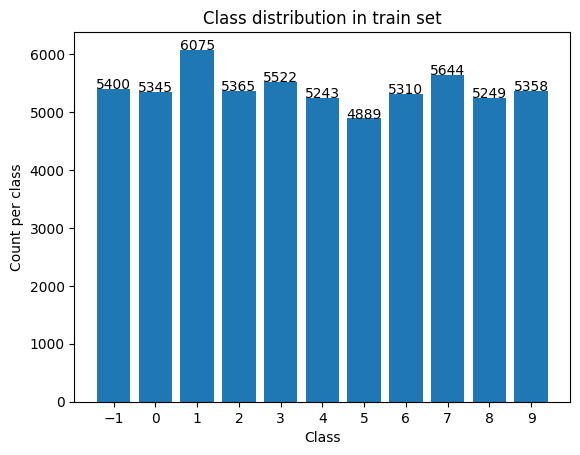

In [ ]:
all_targets = torch.tensor(
    [label[1][5] for label in dataset_train]
).tolist()

counts = Counter(all_targets)
plt.bar(
    list(counts.keys()), list(counts.values()), label=counts.keys()
)
plt.xlabel("Class")
plt.ylabel("Count per class")
plt.title("Class distribution in train set")
for x, y in counts.items():
    plt.text(x, y, f"{y}", ha="center")

plt.xticks([i for i in range(-1,10)])
plt.savefig(save_dir / "class_dist.png")
plt.show()

Looks like there is some class imbalance! However i dont expect this to be a major major problem since most classes are equally balanced. I dont think the model can get away with getting very good at 1 and ignoring the rest of the classes.

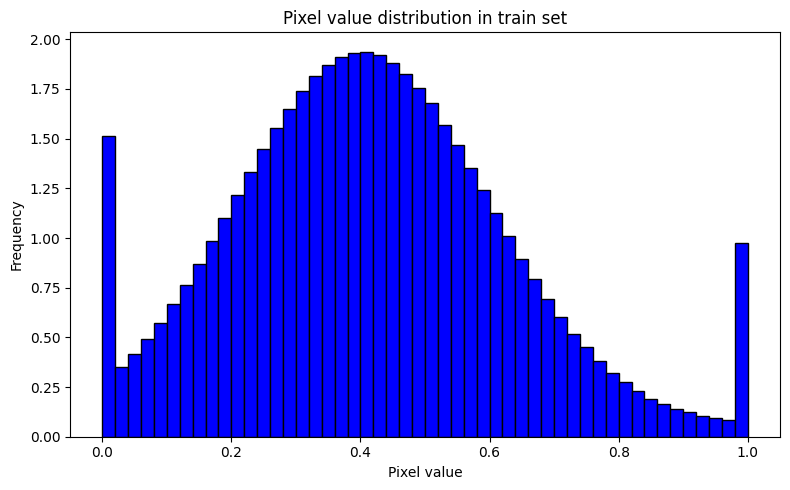

In [ ]:
all_pixels = torch.cat([img_tensor[0].view(-1) for img_tensor in dataset_train])

plt.figure(figsize=(8,5))
plt.hist(all_pixels.numpy(), bins=50, color='blue', edgecolor='black', density=True)
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.title("Pixel value distribution in train set")
plt.tight_layout()
plt.savefig(save_dir / "pixel_dist.png")
plt.show()

Nice! Looks like a normal distribution, but peaks at 0 and 1.

In [ ]:
def grab_pixels_inside_outside_bb(dataset):
    pixels_inside = []
    pixels_outside = []

    for img_tensor, label in dataset:
        z, x, y, w, h, _ = label

        if z == 0:
            pixels_outside.append(img_tensor.view(-1))
            continue

        _, H, W = img_tensor.shape

        x_center = x * W
        y_center = y * H
        w_px = w * W
        h_px = h * H

        x1 = int((x_center - w_px / 2).clamp(0, W))
        x2 = int((x_center + w_px / 2).clamp(0, W))
        y1 = int((y_center - h_px / 2).clamp(0, H))
        y2 = int((y_center + h_px / 2).clamp(0, H))

        img = img_tensor[0]  # shape (H, W)

        # create mask
        mask = torch.zeros(H, W, dtype=torch.bool)
        mask[y1:y2, x1:x2] = True

        pixels_inside.append(img[mask].flatten())
        pixels_outside.append(img[~mask].flatten())

    return torch.cat(pixels_inside), torch.cat(pixels_outside)

pixels_inside, pixels_outside = grab_pixels_inside_outside_bb(dataset_train)

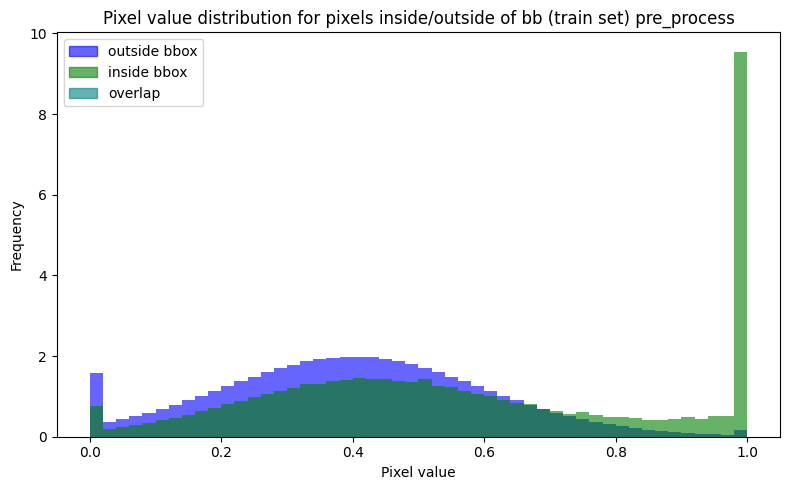

In [ ]:
def pixels_outside_inside_hist(inside, outside, label=""):
    plt.figure(figsize=(8,5))
    plt.hist(outside.numpy(), bins=50, alpha=0.6, color='blue', label='outside bbox', density=True)
    plt.hist(inside.numpy(), bins=50, alpha=0.6, color='green', label='inside bbox', density=True)
    plt.xlabel("Pixel value")
    plt.ylabel("Frequency")
    plt.title(f"Pixel value distribution for pixels inside/outside of bb (train set) {label}")
    plt.legend(handles=[
        Patch(color='blue', alpha=0.6, label='outside bbox'),
        Patch(color='green', alpha=0.6, label='inside bbox'),
        Patch(color='teal', alpha=0.6, label='overlap'),  # blue+green overlap = teal
    ])
    plt.tight_layout()
    plt.savefig(save_dir / f"inside_outside_pixel_dist_{label}.png")
    plt.show()

pixels_outside_inside_hist(pixels_inside, pixels_outside, "pre_process")

Looks like the pixels we are interested in are different than the ones we are not interested in! Lets use this for preprocessing

In [ ]:
def preprocess_out_noise(dataset, threshold=0.8):
    img = dataset[0].clone()
    img[img < threshold] = 0 
    return (img, dataset[1])

dataset_train_processed = [preprocess_out_noise(sample) for sample in dataset_train]
dataset_val_processed = [preprocess_out_noise(sample) for sample in dataset_val]
dataset_test_processed = [preprocess_out_noise(sample) for sample in dataset_test]

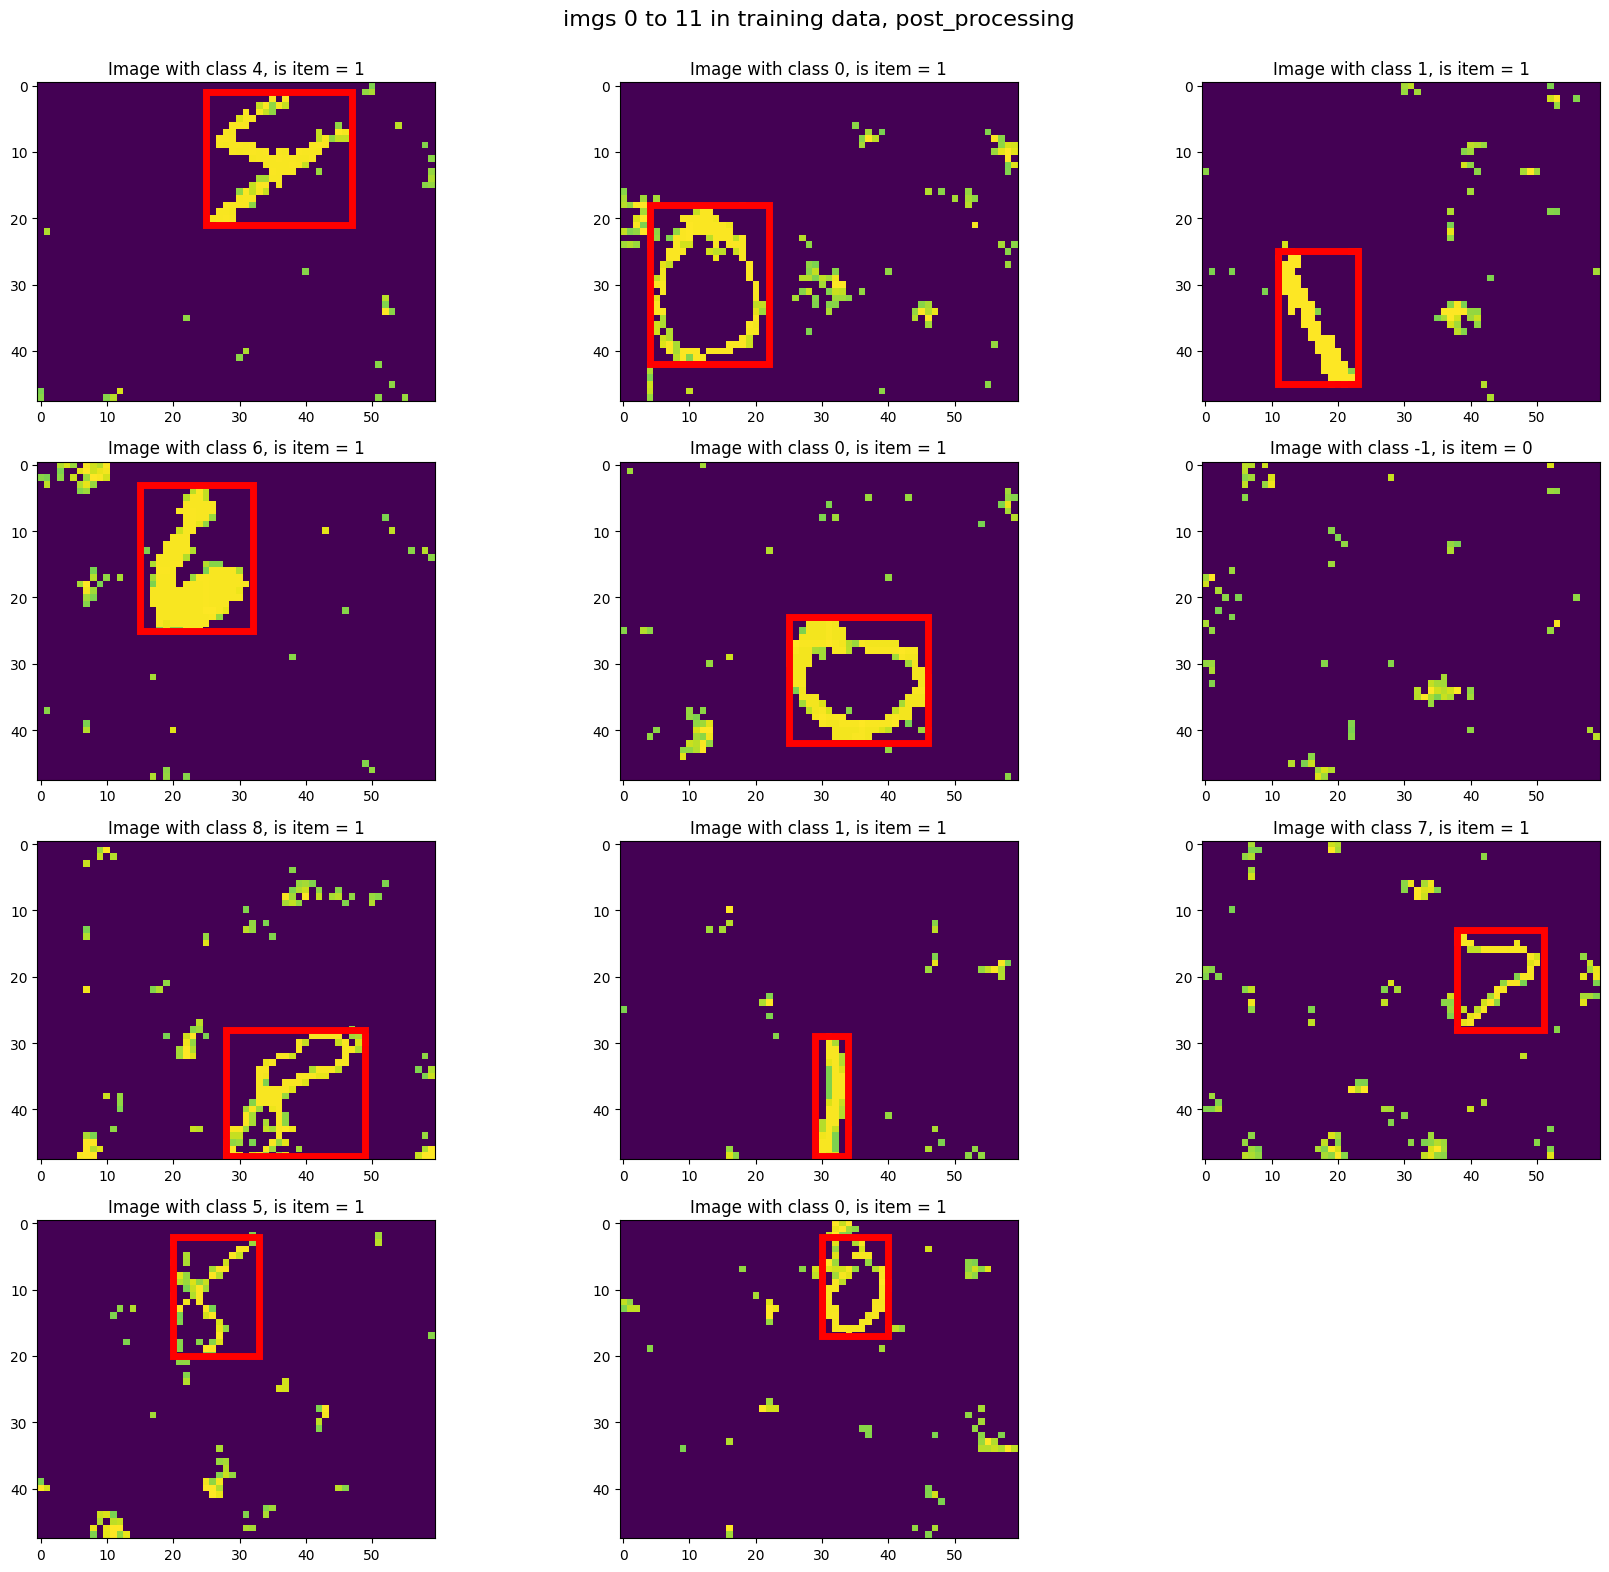

In [ ]:
plot_multiple(
    [i for i in range(11)],
    "imgs 0 to 11 in training data, post_processing",
    dataset_train_processed,
    "data_explore_train_post_process"
)

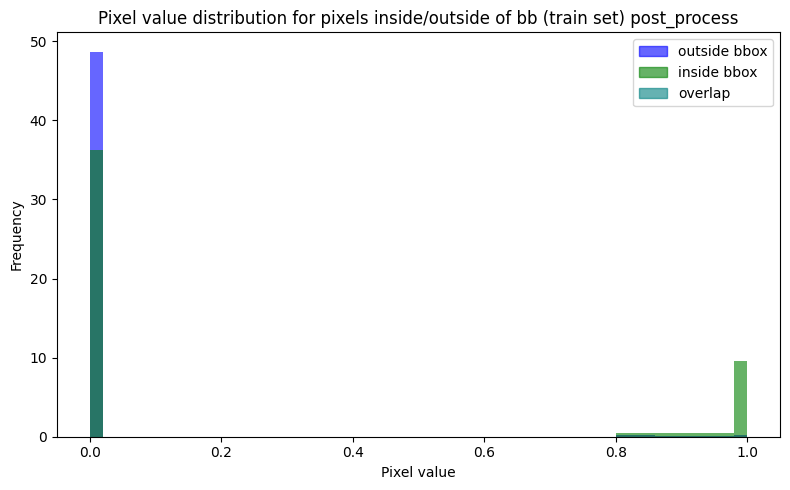

In [ ]:
pixels_inside_processed, pixels_outside_processed = grab_pixels_inside_outside_bb(dataset_train_processed)

pixels_outside_inside_hist(pixels_inside_processed, pixels_outside_processed, "post_process")

Now the images are much less noisy, and without losing a significant amount of data! This might help the model learn, and importantly, it may prevent the model from hallucinating numbers in the images, since the noise that it might misunderstand as numbers is now (hopefully) gone.

In [ ]:
train_loader = DataLoader(dataset_train_processed, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(dataset_val_processed, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset_test_processed, batch_size=BATCH_SIZE, shuffle=False)

# Training

In [ ]:
logits_loss = nn.BCEWithLogitsLoss()
cross_entropy = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

def ObjectDetectionLoss(pred, actual):
    """
    Loss function for a neural network with pred/actual vectors like:
    [
     z : is there an object in the image?
     x : coords
     y : coords
     w : coords
     h : coords
     c1 : class 1 probability
     c2
     c3
     ...
     c_n : class n probability
    ]
    """
    # grab all values
    z_actual, z_pred = actual[:, 0], pred[:, 0]
    class_actual, class_pred = actual[:, 5:], pred[:, 5:]
    bb_actual, bb_pred = actual[:, 1:5], pred[:, 1:5]

    # see what case we are in

    is_object_mask = z_actual == 1

    # both branches do this
    total_loss = logits_loss(z_pred, z_actual) # -log(sigmoid(z)), yes/no loss

    if is_object_mask.any():
        total_loss += mse_loss(bb_pred[is_object_mask], bb_actual[is_object_mask]) # mse per bounding box coords
        total_loss += cross_entropy(class_pred[is_object_mask], class_actual[is_object_mask, 0].long()) # -log(softmax(z)), class loss

    return total_loss

In [ ]:
def train(
    n_epochs,
    optimizer,
    model,
    loss_fn,
    train_loader: DataLoader,
    validation_loader: DataLoader,
):
    n_batch_train = len(train_loader)
    n_batch_val = len(validation_loader)

    losses_train, losses_val = [], []
    train_performance_metrics, val_performance_metrics = {}, {}

    model.train()  # set to train mode
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(1, n_epochs + 1):
        loss_train, loss_val = 0.0, 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device, dtype=torch.float32)
            labels = labels.to(device=device)

            outputs = model(imgs)

            loss = loss_fn(outputs, labels)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            loss_train += loss.item()

        model.eval()  # observe model performance
        with torch.no_grad():
            for val_imgs, val_labels in validation_loader:
                imgs_val = val_imgs.to(device=device, dtype=torch.float32)
                val_labels = val_labels.to(device=device, dtype=torch.float32)
                val_outputs = model(imgs_val)
                val_loss = loss_fn(val_outputs, val_labels)
                loss_val += val_loss.item()

        if epoch in EPOCH_INVESTIGATE_POINTS:
            # map_metric, obj_acc, class_acc
            train_performance_metrics[epoch] = compute_performance_metrics(model, train_loader)
            val_performance_metrics[epoch] = compute_performance_metrics(model, val_loader)

        model.train()

        losses_train.append(loss_train / n_batch_train)
        losses_val.append(loss_val / n_batch_val)

        if epoch == 1 or epoch % 5 == 0:
            print(
                "{}  |  Epoch {}  |  Training loss {:.3f} Validation loss {:.3f}".format(
                    datetime.now().time(), epoch, loss_train / n_batch_train, loss_val / n_batch_val
                )
            )
    return losses_train, losses_val, train_performance_metrics, val_performance_metrics

In [ ]:
class CNNBaseline(nn.Module):
    """
    3 conv into maxpool layers
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2) # 8  × 24 × 30
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2) # 16 × 12 × 15
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2) # 32 × 6 × 7
        self.fc1 = nn.Linear(32 * 6 * 7, 128) # 1344
        self.fc2 = nn.Linear(128, 15)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        # no special output since we are using a custom loss function!
        return x

    def name(self):
        return "CNNBaseline"

In [ ]:
class CNNDeep(nn.Module):
    """
    4 conv into maxpool layers
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2) # 8  × 24 × 30
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2) # 16 × 12 × 15
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2) # 32 × 6 × 7
        self.conv4 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(2, 2) # 64 × 3 × 3
        self.fc1 = nn.Linear(64 * 3 * 3, 256) # 576
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 15)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        # no special output since we are using a custom loss function!
        return x

    def name(self):
        return "CNNDeep"

In [ ]:
class CNNWide(nn.Module):
    """
    3 conv layers, but wider channels
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2) # 32  × 24 × 30
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2) # 64  × 12 × 15
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2) # 128 × 6 × 7
        self.fc1 = nn.Linear(128 * 6 * 7, 256) # 5376
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 15)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        # no special output since we are using a custom loss function!
        return x

    def name(self):
        return "CNNWide"

In [ ]:
def make_model_hash(model, params):
    """Code partially generated by ChatGPT"""
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    buffer.seek(0)
    model_bytes = buffer.read()
    param_bytes = str(sorted(params.items())).encode()
    combined = model_bytes + param_bytes
    return hashlib.sha256(combined).hexdigest()[:10]

In [ ]:
object_detection_loss = ObjectDetectionLoss

In [ ]:
def plot_train_val_losses(
    train_losses,
    val_losses,
    train_acc,
    val_acc,
    params: dict = None,
    ax=None,
    title=None,
):
    if ax is None:
        _fig, ax = plt.subplots(figsize=(10, 6))

    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, label="train loss")
    ax.plot(epochs, val_losses, label="val loss")

    if title:
        ax.set_title(title, pad=20)

    cell_text = []
    row_labels = ["val class_acc", "val_obj_acc", "val_iou"]

    row_class = []
    row_obj = []
    row_iou = []

    y_max = max(max(train_losses), max(val_losses))
    y_offset = 0.05 * y_max  # small offset above curves

    for epoch in EPOCH_INVESTIGATE_POINTS:
        v_iou, v_obj_acc, v_class_acc = val_acc[epoch]
        t_iou, t_obj_acc, t_class_acc = train_acc[epoch]

        row_class.append(f"{v_class_acc:.2f}")
        row_obj.append(f"{v_obj_acc:.2f}")
        row_iou.append(f"{v_iou:.2f}")

        ax.axvline(x=epoch, color="gray", linestyle="--", alpha=0.3)

        # text above the curves
        ax.text(
            epoch,
            y_max + y_offset,
            f"val_score: {((v_iou + v_class_acc) / 2):.2f}",
            color="orange",
            fontsize=9,
            ha="center",
            va="bottom",
        )
        ax.text(
            epoch,
            y_max + 2 * y_offset,
            f"train_score: {((t_iou + t_class_acc) / 2):.2f}",
            color="blue",
            fontsize=9,
            ha="center",
            va="bottom",
        )

    cell_text.append(row_class)
    cell_text.append(row_obj)
    cell_text.append(row_iou)

    performance_table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=[f"Epoch {e}" for e in EPOCH_INVESTIGATE_POINTS],
        loc='bottom',
        cellLoc='center',
        bbox=[0.0, -0.35, 1.0, 0.2] # [left, bottom, width, height] relative to axes
    )

    performance_table.auto_set_font_size(False)
    performance_table.set_fontsize(9)

    # https://matplotlib.org/stable/gallery/text_labels_and_annotations/placing_text_boxes.html
    if params:
        param_text = "\n".join([f"{key} : {value}" for key, value in params.items()])
        props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
        ax.text(
            x=0.05,
            y=0.05,
            s=param_text,
            transform=ax.transAxes,
            verticalalignment="bottom",
            bbox=props,
        )

    ax.legend()
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Total Loss")

    # Adjust layout to make room for the table below the X-axis
    plt.subplots_adjust(left=0.2, bottom=0.3)

    return ax

In [ ]:
def plot_all_runs(runs: list, model_title: str):
    n = len(runs)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    fig.suptitle(f"All runs for model type {model_title}", fontsize=16)

    for ax, model_outcome in zip(axes, runs):
        plot_train_val_losses(
            train_losses=model_outcome.train_losses,
            val_losses=model_outcome.val_losses,
            train_acc=model_outcome.train_accuracies,
            val_acc=model_outcome.validation_accuracies,
            params=model_outcome.params,
            ax=ax,
        )

    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(save_dir / f"hyperparams_{model_title}.png", dpi=500)

    plt.show()

In [ ]:
model_baseline = CNNBaseline().to(device)

In [ ]:
if DO_TRAINING:
    object_detection_optimizer = optim.Adam(model_baseline.parameters())

    train_losses, validation_losses, train_performance_metrics, val_performance_metrics = train(
        n_epochs=MAX_EPOCHS,
        optimizer=object_detection_optimizer,
        model=model_baseline,
        loss_fn=object_detection_loss,
        train_loader=train_loader,
        validation_loader=val_loader,
    )

00:08:26.256427  |  Epoch 1  |  Training loss 1.860 Validation loss 1.420
00:09:59.909901  |  Epoch 5  |  Training loss 0.446 Validation loss 0.568
00:12:04.782177  |  Epoch 10  |  Training loss 0.198 Validation loss 0.818


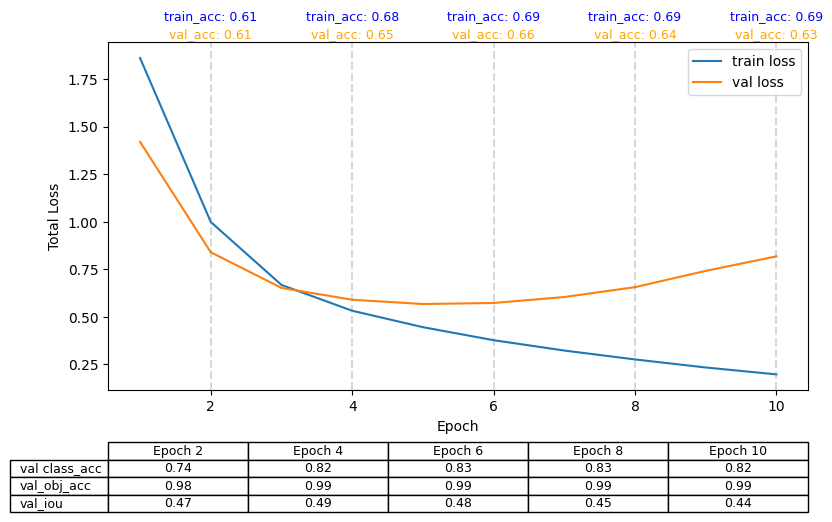

In [ ]:
if DO_TRAINING:
    baseline_plot = plot_train_val_losses(
        train_losses=train_losses,
        val_losses=validation_losses,
        train_acc=train_performance_metrics,
        val_acc=val_performance_metrics,
        params={
            "model" : "CNNBaseline"
        },
    )
    baseline_plot

In [ ]:
class ModelOutcome:
    def __init__(
        self,
        train_losses: list,
        val_losses: list,
        params: dict,
        train_performance_metrics: list[float],
        val_performance_metrics: list[float],
        model_path: Path,
    ):
        self.train_losses = train_losses
        self.val_losses = val_losses

        self.params = params

        self.train_performance_metrics = train_performance_metrics
        self.val_performance_metrics = val_performance_metrics

        self.model_path = model_path

    def to_dict(self) -> dict:
        return {
            "train_losses": self.train_losses,
            "val_losses": self.val_losses,
            "params": self.params,
            "train_performance_metrics": self.train_performance_metrics,
            "val_performance_metrics": self.val_performance_metrics,
            "model_path": str(self.model_path) if self.model_path else None,
        }

    @staticmethod
    def from_dict(d: dict):
        return ModelOutcome(
            train_losses=d["train_losses"],
            val_losses=d["val_losses"],
            params=d["params"],
            train_performance_metrics={int(k): v for k, v in d["train_performance_metrics"].items()},
            val_performance_metrics={int(k): v for k, v in d["val_performance_metrics"].items()},
            model_path=Path(d["model_path"]) if d.get("model_path") else None,
        )

In [ ]:
learning_rate_ls = [1e-3, 1e-4]
weight_decay_ls = [0, 1e-4]

models = [CNNBaseline, CNNWide, CNNDeep]

In [ ]:
all_model_outcomes: dict[list[ModelOutcome]] = {}

if DO_TRAINING:
    models_dir = Path("models")
    models_dir.mkdir(exist_ok=True)

    for model_class in models:
        params_and_losses: list[ModelOutcome] = []

        perms = product(learning_rate_ls, weight_decay_ls)
        model_count = (
            len(learning_rate_ls) * len(weight_decay_ls)
        )

        for index, hyperparams in enumerate(perms):
            torch.manual_seed(SEED)

            learning_rate, weight_decay = hyperparams
            model = model_class().to(device)

            optimizer = optim.Adam(
                model.parameters(),
                lr=learning_rate,
                weight_decay=weight_decay,
            )

            train_losses, validation_losses, train_performance_metrics, val_performance_metrics = train(
                n_epochs=MAX_EPOCHS,
                optimizer=optimizer,
                model=model,
                loss_fn=object_detection_loss,
                train_loader=train_loader,
                validation_loader=val_loader,
            )
            print(f"Trained {index} of {model_count} model permuations")

            params = {
                "model": model.name(),
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
            }

            model_hash = make_model_hash(model, params)
            model_path = models_dir / f"{model_hash}.pt"

            torch.save(model.state_dict(), model_path)

            model_outcome = ModelOutcome(
                train_losses=train_losses,
                val_losses=validation_losses,
                params=params,
                train_performance_metrics=train_performance_metrics,
                val_performance_metrics=val_performance_metrics,
                model_path=model_path,
            )

            params_and_losses.append(model_outcome)

        print(f"Finished training {model.name()}")
        all_model_outcomes[model.name()] = params_and_losses

    all_model_outcomes.keys()

23:02:24.117191  |  Epoch 1  |  Training loss 1.860 Validation loss 1.420
23:03:51.465964  |  Epoch 5  |  Training loss 0.446 Validation loss 0.568


KeyboardInterrupt: 

In [ ]:
output_path = Path("data/saved/model_outcomes.json")

In [ ]:
if DO_TRAINING:
    json.dump(
        {k: [m.to_dict() for m in v] for k, v in all_model_outcomes.items()},
        output_path.open("w"),
    )

In [ ]:
runs = all_model_outcomes["CNNBaseline"]
plot_all_runs(runs, "CNNBasline")

In [ ]:
runs = all_model_outcomes["CNNDeep"]
plot_all_runs(runs, "CNNDeep")

In [ ]:
runs = all_model_outcomes["CNNWide"]
plot_all_runs(runs, "CNNWide")

### Model selection

In [ ]:
best_model_outcome = None
best_score = -1.0
best_metrics = None
best_epoch = None

for model_name, runs in all_model_outcomes.items():
    for run in runs:
        for epoch, metrics in run.val_performance_metrics.items():
            val_iou, val_obj_acc, val_class_acc = metrics

            # from pdf, this is overall performance
            current_score = (val_iou + val_class_acc) / 2

            if current_score > best_score:
                best_score = current_score
                best_metrics = metrics
                best_model_outcome = run
                best_epoch = epoch

print(f"Best model: {best_model_outcome.params['model']}")
print(f"Best Score: {best_score:.4f} (Metrics: {best_metrics}) at {best_epoch} epochs")
print(f"Model path: {best_model_outcome.model_path}")

In [ ]:
best_plot = plot_train_val_losses(
    train_losses=best_model_outcome.train_losses,
    val_losses=best_model_outcome.val_losses,
    train_acc=best_model_outcome.train_performance_metrics,
    val_acc=best_model_outcome.validation_performance_metrics,
    params=best_model_outcome.params,
)
plt.savefig(save_dir / "best_model.png")
plt.show()

In [ ]:
model_class_name = best_model_outcome.params["model"]

if model_class_name == "CNNBaseline":
    best_model = CNNBaseline().to(device)
elif model_class_name == "CNNWide":
    best_model = CNNWide().to(device)
elif model_class_name == "CNNDeep":
    best_model = CNNDeep().to(device)

In [ ]:
best_model.load_state_dict(torch.load(best_model_outcome.model_path))
best_model.eval()

CNNBaseline(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1344, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=15, bias=True)
)

### Prediction

In [ ]:
def grab_predictions(model, dataset):
    all_preds = []
    all_actual = []
    
    with torch.no_grad():
        for imgs, actual_vector in dataset:
            imgs = imgs.to(device, dtype=torch.float32)
            actual_vector = actual_vector.to(device)
            
            pred_vector = model(imgs)
            
            all_preds.append(pred_vector.cpu())
            all_actual.append(actual_vector.cpu())
    
    return torch.cat(all_preds, dim=0), torch.cat(all_actual, dim=0)

In [ ]:
def confusion_matrix_custom(actual, pred, title, type: str, iters):
    # fix display labels must match!
    """Code partially generated by ChatGPT"""
    
    cm = confusion_matrix(actual, pred)
    cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    cm_percent = np.nan_to_num(cm_percent)

    _fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # all
    disp1 = ConfusionMatrixDisplay(
        confusion_matrix=cm,
          display_labels=[i for i in iters]
    )
    disp1.plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
    axes[0].set_title(f"Counts: {title}")

    # percentages
    disp2 = ConfusionMatrixDisplay(
        confusion_matrix=cm_percent, 
        display_labels=[i for i in iters]
    )
    disp2.plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=True, values_format=".1f")
    axes[1].set_title(f"Percentages: {title}")

    plt.tight_layout()
    plt.savefig(save_dir / f"{title}_{type}.png")
    plt.show()

In [ ]:
def get_rmse_bounding_boxes_per_class(all_preds, all_actual, all_actual_labels, set_label):
    rmse_dict = {}

    labels_int = all_actual_labels.astype(int)

    for cls in range(0,10):
        indexes = np.where(labels_int == cls)
        rmse_dict[cls] = compute_rmse_arrs(all_actual[indexes], all_preds[indexes])

    plt.bar(
        list(rmse_dict.keys()), list(rmse_dict.values()), label=rmse_dict.keys()
    )

    plt.xlabel("Class")
    plt.ylabel("Bounding box RMSE")
    plt.title(f"Bounding box RMSE per class distribution in {set_label} set")
    plt.xticks([i for i in range(0,10)])
    plt.savefig(save_dir / f"bb_rmse_{set_label}.png")
    plt.show()

### Model evaluation

In [ ]:
all_preds_train, all_actual_train = grab_predictions(best_model, train_loader)
all_preds_val, all_actual_val = grab_predictions(best_model, train_loader)
all_preds_test, all_actual_test = grab_predictions(best_model, test_loader)

/tmp/ipykernel_481091/225152982.py:6: RuntimeWarning: invalid value encountered in divide
  cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100


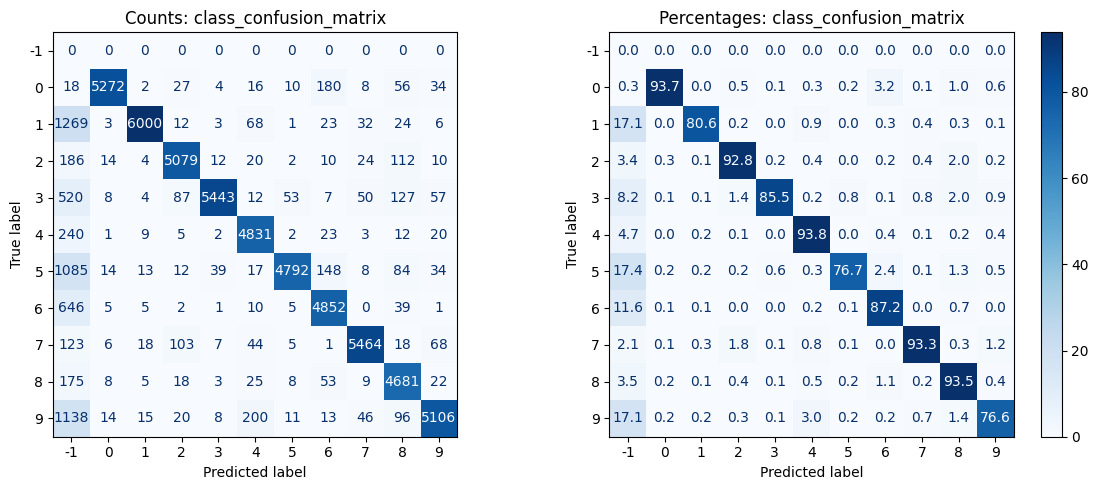

In [ ]:
# accuracy class
def conf_matrix_class(all_preds, all_actual, dataset: str):
    pred_labels = all_preds[:, 5:].argmax(dim=1)
    actual_labels = all_actual[:, 5].long()

    confusion_matrix_custom(pred_labels.numpy(), actual_labels.numpy(), f"class_confusion_matrix_{dataset}", "train", iters=range(-1,10))

conf_matrix_class(all_preds_train, all_actual_train, "train")
conf_matrix_class(all_preds_val, all_actual_val, "val")
conf_matrix_class(all_preds_test, all_actual_test, "test")

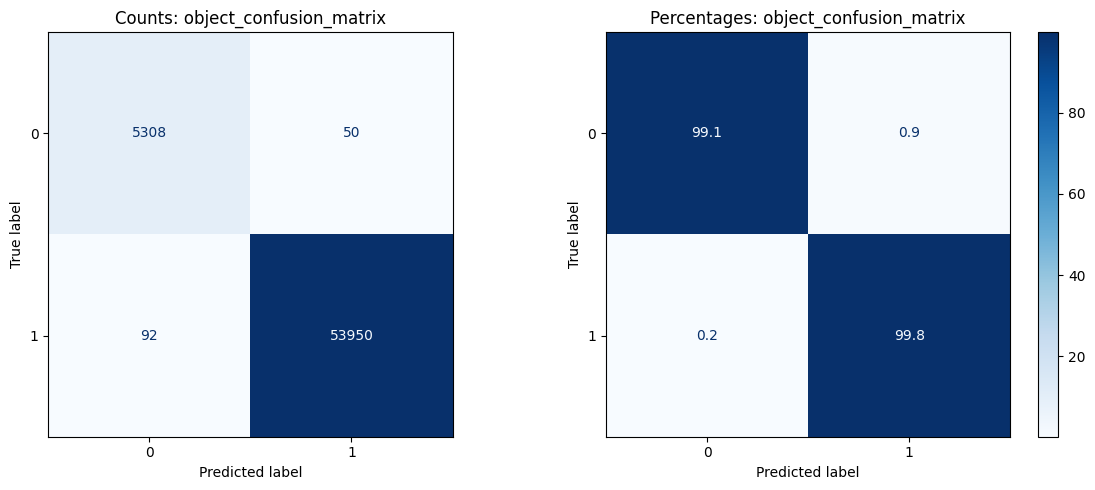

In [ ]:
# accuracy object
def conf_matrix_obj(all_preds, all_actual, dataset: str):
    pred_object = (torch.sigmoid(all_preds[:, 0]) > 0.5).long()
    actual_object = all_actual[:, 0].long()

    confusion_matrix_custom(
        pred_object.numpy(), actual_object.numpy(), f"object_confusion_matrix_{dataset}", "train", iters = range(0,2)
    )

conf_matrix_obj(all_preds_train, all_actual_train, "train")
conf_matrix_obj(all_preds_val, all_actual_val, "val")
conf_matrix_obj(all_preds_test, all_actual_test, "test")

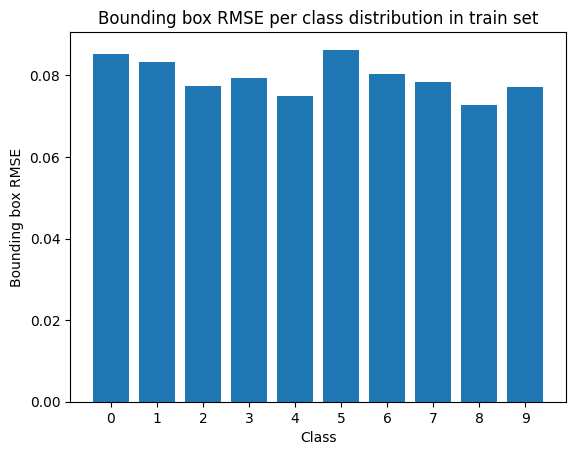

In [ ]:
# accuracy bounding boxes
# only compute bbox RMSE on images where object actually exists

def rmse_bb(all_preds, all_actual, dataset: str):
    actual_bb = all_actual[all_actual[:, 0] == 1, 1:5]
    pred_bb = all_preds[all_actual[:, 0] == 1, 1:5]
    all_actual_labels = all_actual[all_actual[:, 0] == 1, 5]

    get_rmse_bounding_boxes_per_class(pred_bb.numpy(), actual_bb.numpy(), all_actual_labels.numpy(), dataset)

rmse_bb(all_preds_train, all_actual_train, "train")
rmse_bb(all_preds_val, all_actual_val, "val")
rmse_bb(all_preds_test, all_actual_test, "test")

/tmp/ipykernel_481091/1958081697.py:43: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(


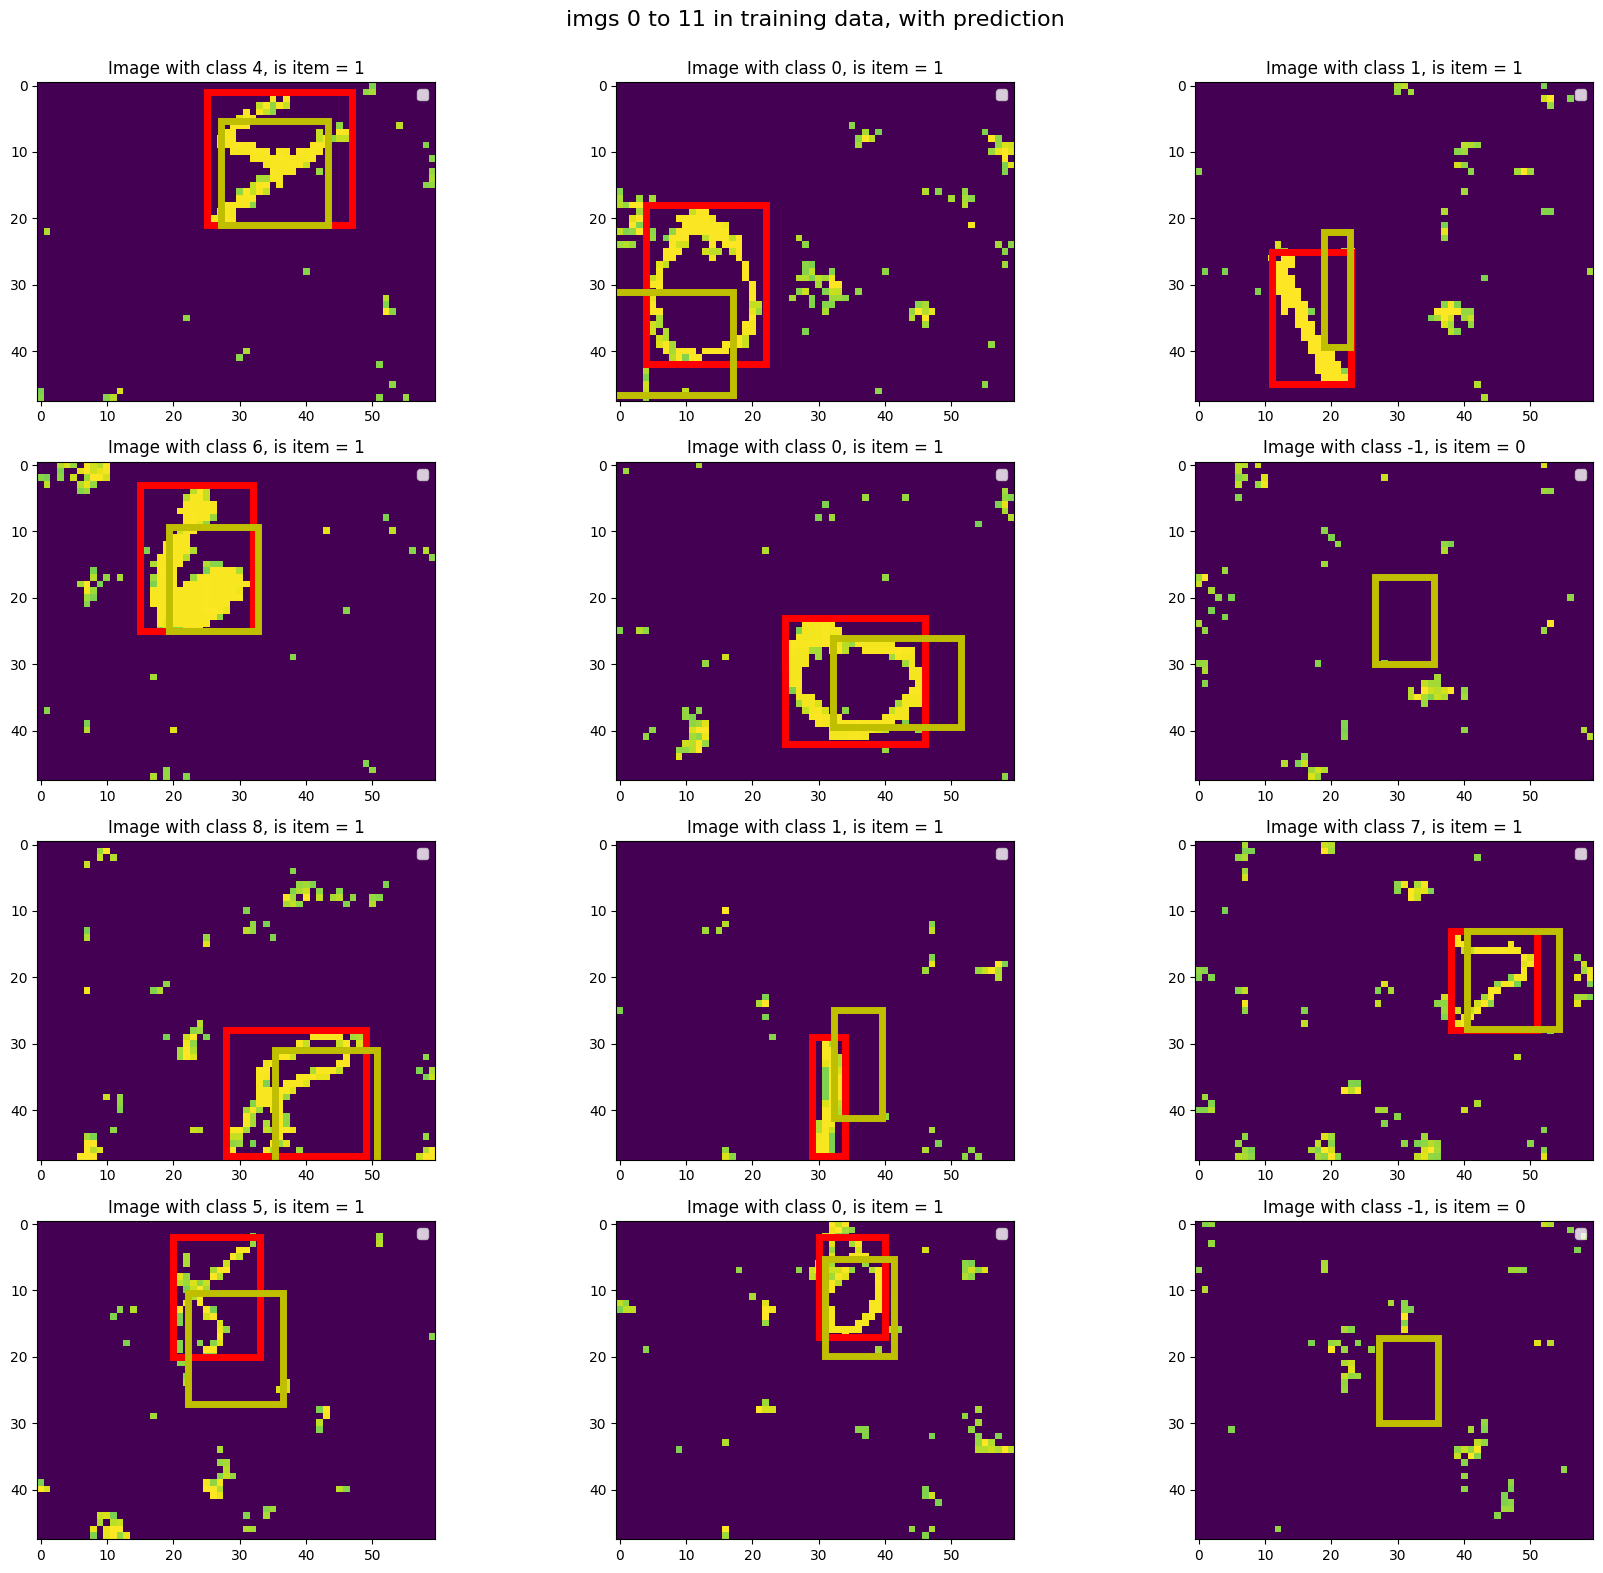

In [ ]:
img_to_show = 12
preds_test = [all_preds_test[i, 1:5] for i in range(img_to_show)]
plot_multiple_with_prediction(
    [i for i in range(img_to_show)],
    preds_test,
    "imgs 0 to 11 in test data, with prediction",
    dataset_test_processed,
    "data_predict_train"
)

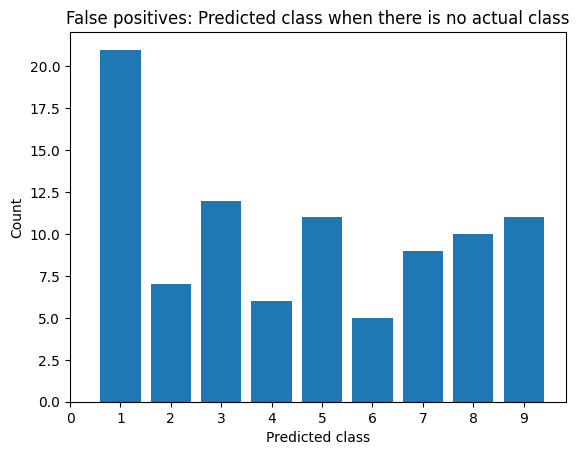

In [ ]:
def fp(all_preds, all_actual, dataset: str):
    pred_object = (torch.sigmoid(all_preds[:, 0]) > 0.5).long()
    actual_object = all_actual[:, 0].long()

    fp_mask = (pred_object == 1) & (actual_object == 0)
    predicted_classes = all_preds[fp_mask, 5:].argmax(dim=1)

    counts = Counter(predicted_classes.numpy().tolist())

    plt.bar(
        list(counts.keys()), list(counts.values()), label=counts.keys()
    )

    plt.title(f"False positives: Predicted class when there is no actual class in {dataset}")
    plt.xlabel("Predicted class")
    plt.ylabel("Count")
    plt.xticks(range(10))
    plt.savefig(save_dir / f"false_positives_{dataset}.png")
    plt.show()

fp(all_preds_train, all_actual_train, "train")
fp(all_preds_val, all_actual_val, "val")
fp(all_preds_test, all_actual_test, "test")

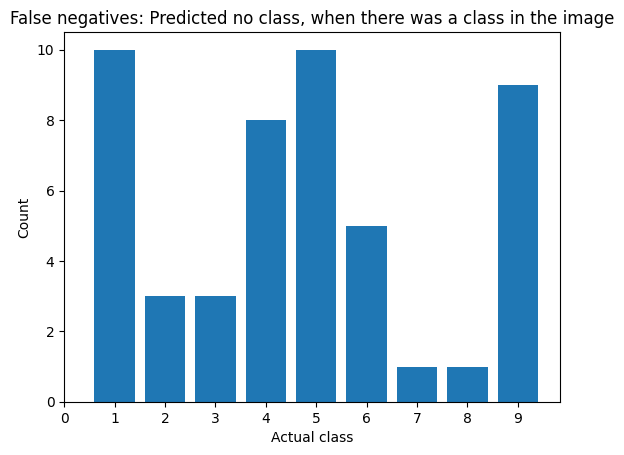

In [ ]:
def fn(all_preds, all_actual, dataset: str):
    pred_object = (torch.sigmoid(all_preds[:, 0]) > 0.5).long()
    actual_object = all_actual[:, 0].long()

    fn_mask = (pred_object == 0) & (actual_object == 1)
    predicted_classes = all_preds[fn_mask, 5:].argmax(dim=1)

    counts = Counter(predicted_classes.numpy().tolist())

    plt.bar(
        list(counts.keys()), list(counts.values()), label=counts.keys()
    )

    plt.title(f"False negatives: Predicted no class, when there was a class in the image, in {dataset}")
    plt.xlabel("Actual class")
    plt.ylabel("Count")
    plt.xticks(range(10))
    plt.savefig(save_dir / f"false_positives_{dataset}.png")
    plt.show()

fn(all_preds_train, all_actual_train, "train")
fn(all_preds_val, all_actual_val, "val")
fn(all_preds_test, all_actual_test, "test")